In [1]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
import sqlite3
import seaborn as sns

conn = sqlite3.connect('../data/mental_health.sqlite')

df = pd.read_sql("""
    SELECT a.UserID, a.SurveyID, a.AnswerText, q.questiontext
    FROM Answer a
    JOIN Question q ON a.QuestionID = q.questionid
""", conn)

df_wide = df.pivot_table(
    index=['UserID', 'SurveyID'],
    columns='questiontext',
    values='AnswerText',
    aggfunc='first'
).reset_index()

threshold = 50
df_clean = df_wide.loc[:, df_wide.isnull().sum() / len(df_wide) * 100 < threshold]

cols_to_drop = ['UserID', 'If you live in the United States, which state or territory do you live in?',
                'What US state or territory do you work in?', 'What country do you live in?',
                'What country do you work in?']
df_clean = df_clean.drop(columns=cols_to_drop)

df_clean['What is your age?'] = pd.to_numeric(df_clean['What is your age?'], errors='coerce')
df_clean = df_clean[df_clean['What is your age?'].between(18, 80)]

def clean_gender(g):
    if pd.isna(g): return None
    g = str(g).strip().lower()
    if g in ['male', 'm', 'man', 'cis male', 'cis man', 'masculine', 'masculino', 'mail', 'malr', 'sex is male']:
        return 'Male'
    elif g in ['female', 'f', 'woman', 'cis female', 'cis woman', 'feminine', 'femail', 'femake', 'female (cis)']:
        return 'Female'
    else:
        return 'Other'

df_clean['What is your gender?'] = df_clean['What is your gender?'].apply(clean_gender)

df_model = df_clean.dropna()

target_col = 'Have you ever sought treatment for a mental health disorder from a mental health professional?'

# Target Variable Distribution

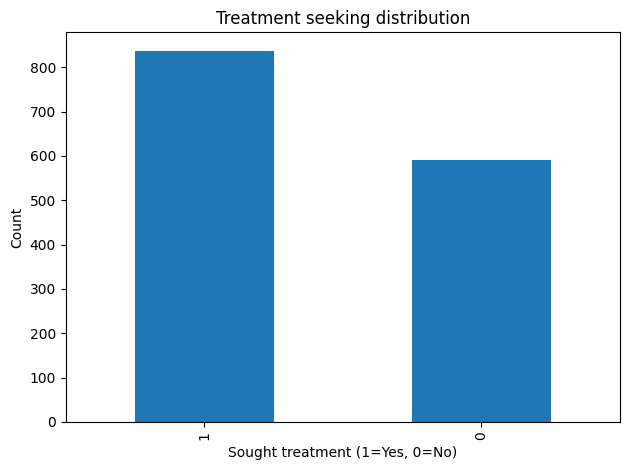

In [4]:
df_model[target_col].value_counts().plot(kind='bar')
plt.title('Treatment seeking distribution')
plt.xlabel('Sought treatment (1=Yes, 0=No)')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Age Distribution

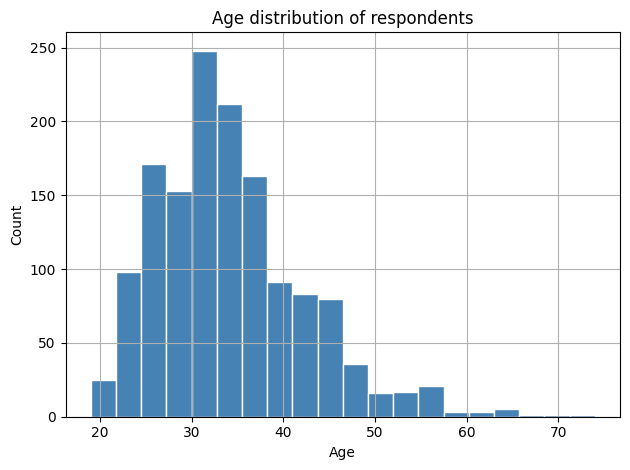

In [5]:
df_model['What is your age?'].astype(float).hist(bins=20, color='steelblue', edgecolor='white')
plt.title('Age distribution of respondents')
plt.xlabel('Age')
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Gender Distribution

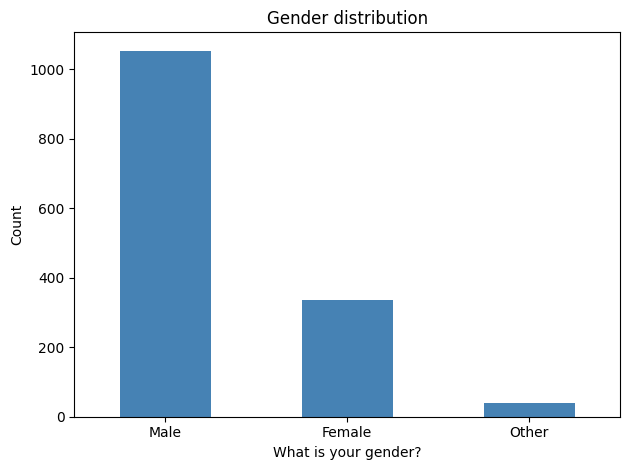

In [6]:
df_model['What is your gender?'].value_counts().plot(kind='bar', color='steelblue')
plt.title('Gender distribution')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.tight_layout()
plt.show()

# Treatment Seeking by Gender

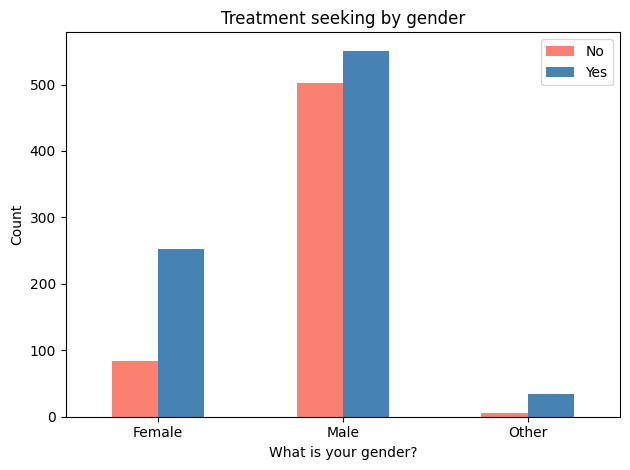

In [7]:
pd.crosstab(df_model['What is your gender?'], 
            df_model[target_col]).plot(kind='bar', color=['salmon', 'steelblue'])
plt.title('Treatment seeking by gender')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.legend(['No', 'Yes'])
plt.tight_layout()
plt.show()

# Family History vs Treatment

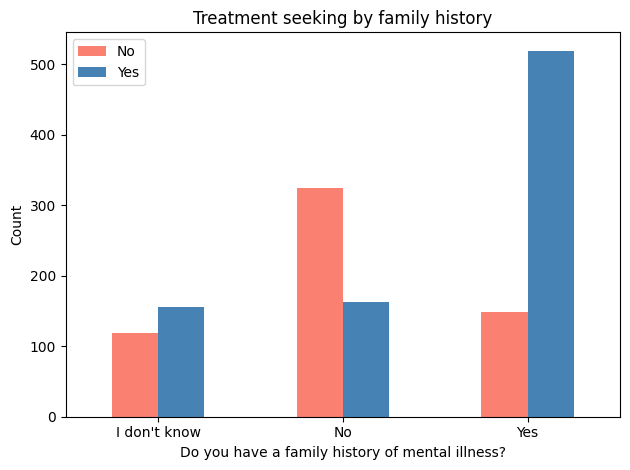

In [8]:
pd.crosstab(df_model['Do you have a family history of mental illness?'], 
            df_model[target_col]).plot(kind='bar', color=['salmon', 'steelblue'])
plt.title('Treatment seeking by family history')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.legend(['No', 'Yes'])
plt.tight_layout()
plt.show()

# Current Diagnosis

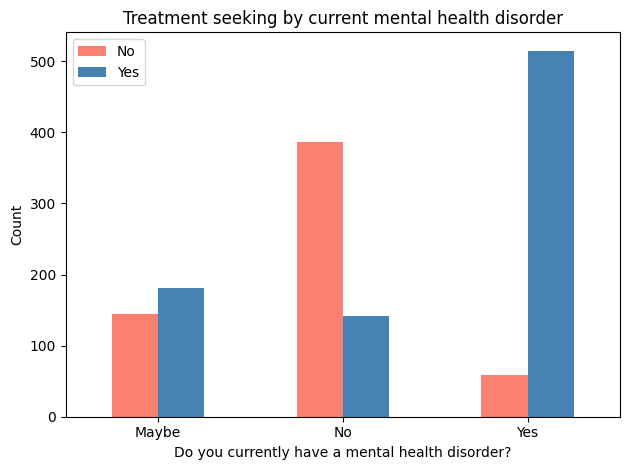

In [9]:
pd.crosstab(df_model['Do you currently have a mental health disorder?'], 
            df_model[target_col]).plot(kind='bar', color=['salmon', 'steelblue'])
plt.title('Treatment seeking by current mental health disorder')
plt.xticks(rotation=0)
plt.ylabel('Count')
plt.legend(['No', 'Yes'])
plt.tight_layout()
plt.show()

# Age vs Treatment 

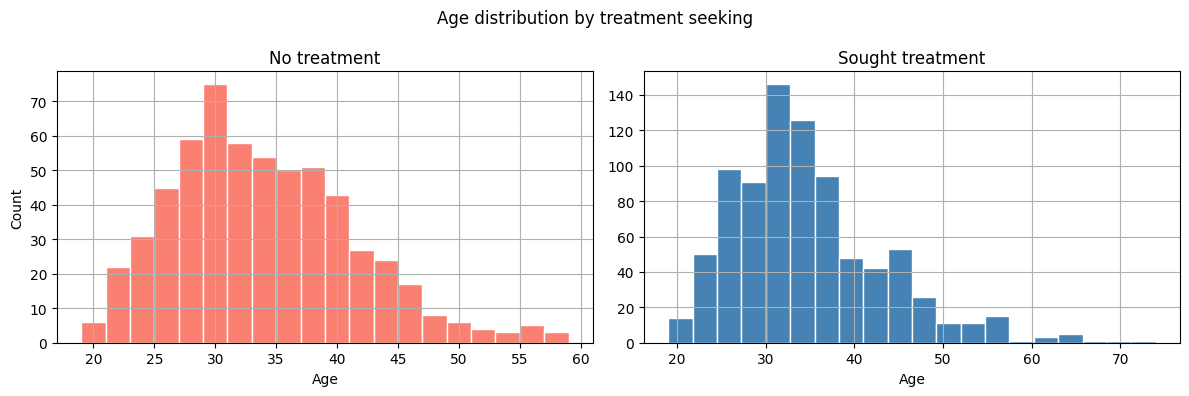

In [13]:
fig, axes = plt.subplots(1, 2, figsize=(12, 4))

no_treatment.hist(bins=20, ax=axes[0], color='salmon', edgecolor='white')
axes[0].set_title('No treatment')
axes[0].set_xlabel('Age')
axes[0].set_ylabel('Count')

yes_treatment.hist(bins=20, ax=axes[1], color='steelblue', edgecolor='white')
axes[1].set_title('Sought treatment')
axes[1].set_xlabel('Age')

plt.suptitle('Age distribution by treatment seeking')
plt.tight_layout()
plt.show()

## Key findings

- 58% of respondents sought treatment, 42% did not — healthy class balance
- Women seek treatment proportionally more than men
- Family history of mental illness is a strong predictor of seeking treatment
- Current mental health diagnosis is the strongest predictor
- Age shows mild pattern — peak treatment seekers around 30